Saving cleaned_churn_data.csv to cleaned_churn_data.csv
   Count         City   Latitude   Longitude  Gender Senior Citizen Partner  \
0      1  Los Angeles  33.964131 -118.272783    Male             No      No   
1      1  Los Angeles  34.059281 -118.307420  Female             No      No   
2      1  Los Angeles  34.048013 -118.293953  Female             No      No   
3      1  Los Angeles  34.062125 -118.315709  Female             No     Yes   
4      1  Los Angeles  34.039224 -118.266293    Male             No      No   

  Dependents  Tenure Months Phone Service  ...        Contract  \
0         No              2           Yes  ...  Month-to-month   
1        Yes              2           Yes  ...  Month-to-month   
2        Yes              8           Yes  ...  Month-to-month   
3        Yes             28           Yes  ...  Month-to-month   
4        Yes             49           Yes  ...  Month-to-month   

  Paperless Billing             Payment Method Monthly Charges Total Cha

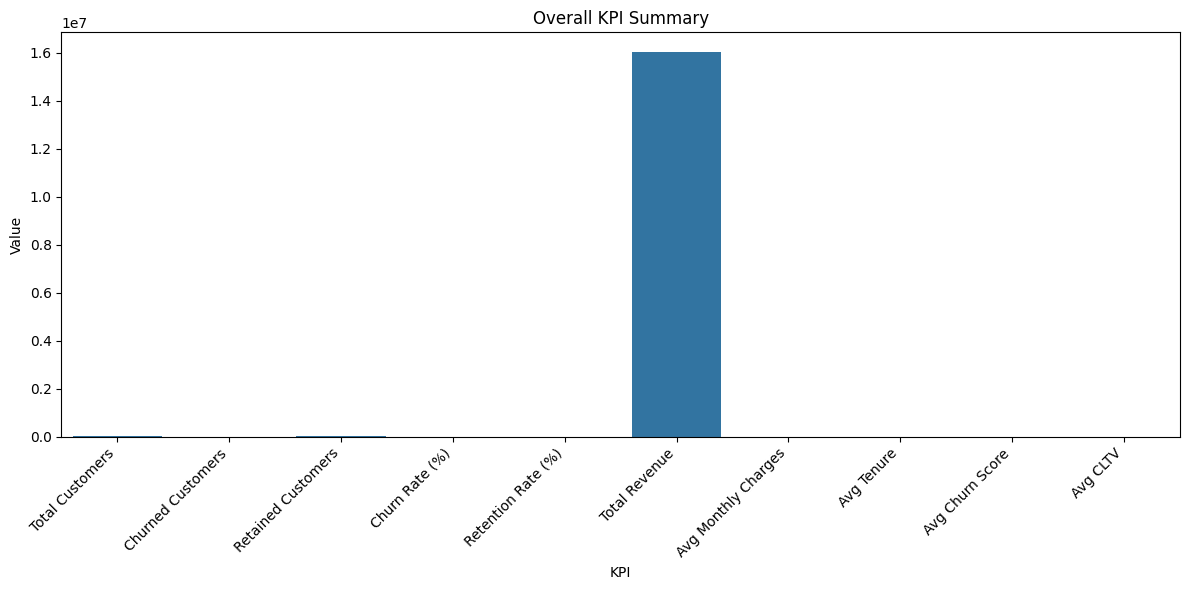

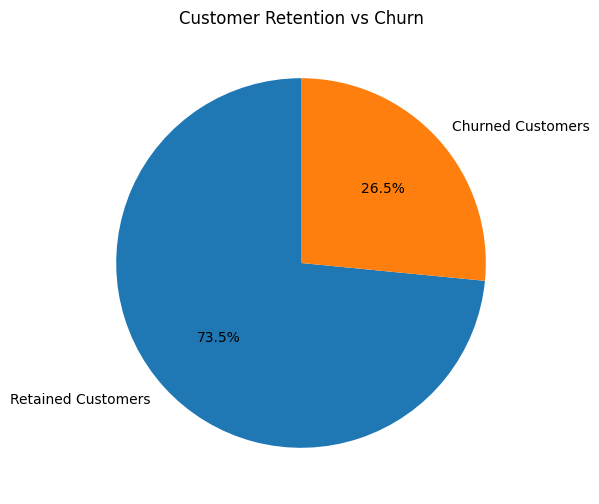

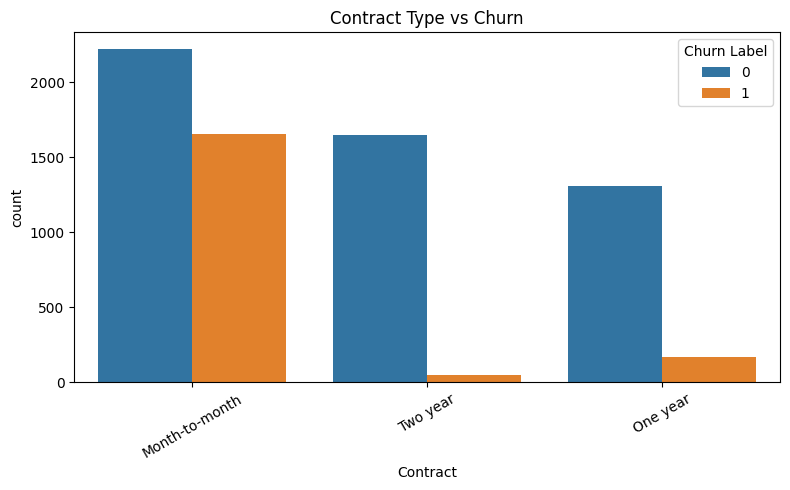

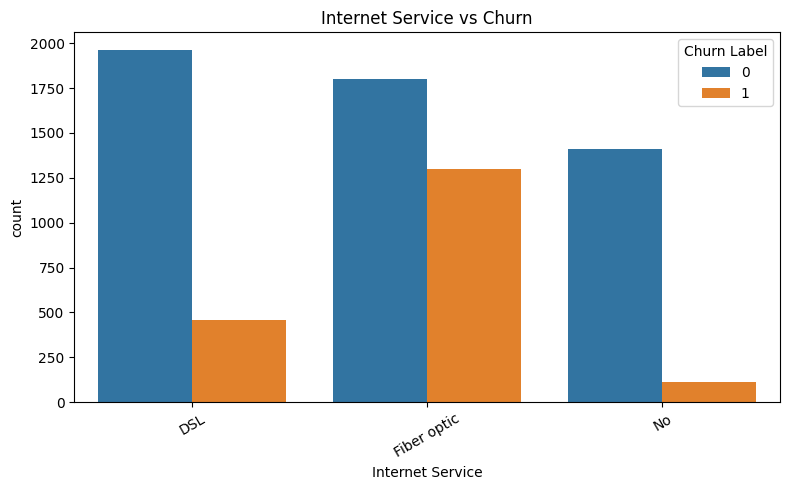

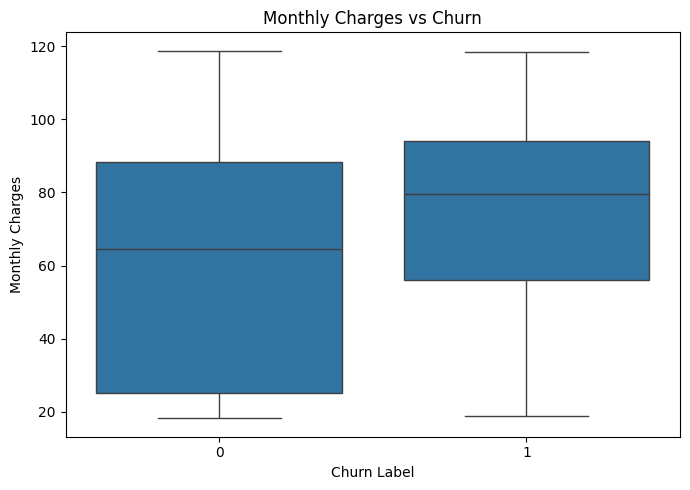

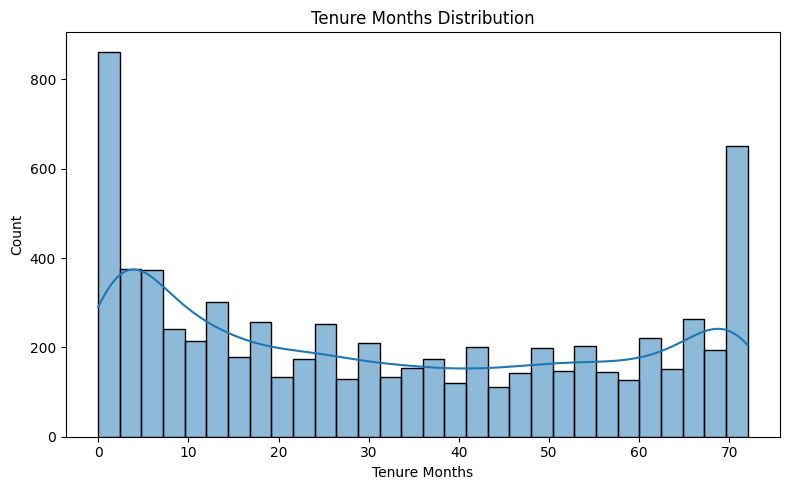

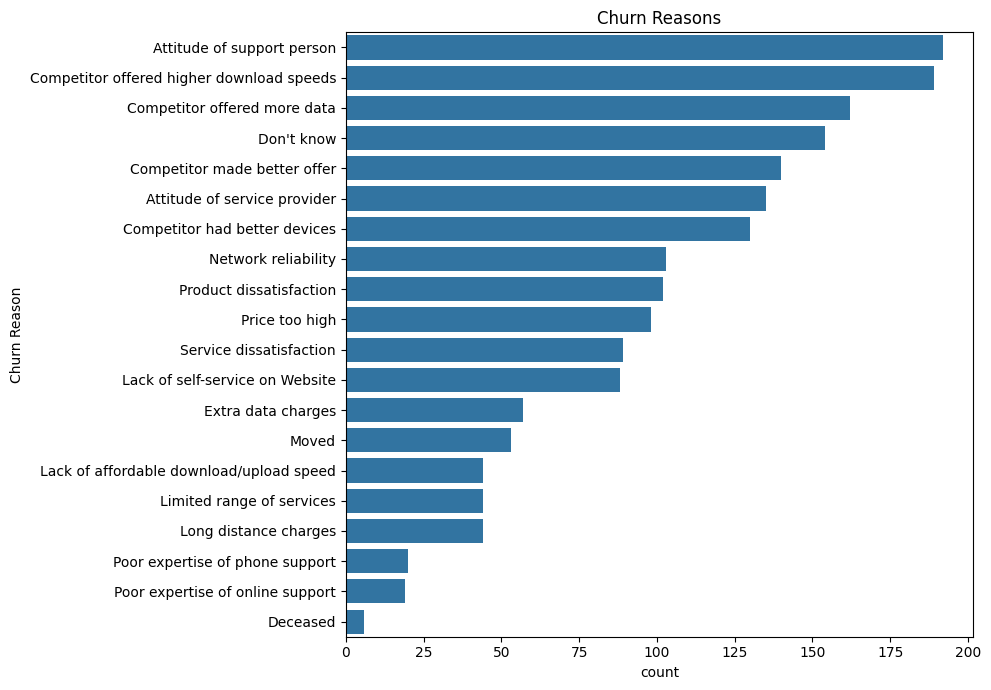

KPI charts PDF created successfully!


In [1]:
# =========================================
# CUSTOMER CHURN KPI ANALYSIS + CHARTS
# GOOGLE COLAB COMPLETE CODE
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

# =========================================
# 1. UPLOAD DATASET
# =========================================

uploaded = files.upload()

# After upload, use your cleaned file name
df = pd.read_csv("cleaned_churn_data.csv")

# =========================================
# 2. BASIC CHECK
# =========================================

print(df.head())
print(df.info())

# =========================================
# 3. KPI CALCULATIONS
# =========================================

total_customers = df["Count"].sum()

churned_customers = df[df["Churn Value"] == 1]["Count"].sum()

retained_customers = df[df["Churn Value"] == 0]["Count"].sum()

churn_rate = (churned_customers / total_customers) * 100

retention_rate = (retained_customers / total_customers) * 100

total_revenue = df["Total Charges"].sum()

avg_monthly_charges = df["Monthly Charges"].mean()

avg_tenure = df["Tenure Months"].mean()

avg_churn_score = df["Churn Score"].mean()

avg_cltv = df["CLTV"].mean()

# =========================================
# 4. PRINT KPI VALUES
# =========================================

print("========== KPI RESULTS ==========")
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Retention Rate:", round(retention_rate, 2), "%")
print("Total Revenue:", round(total_revenue, 2))
print("Average Monthly Charges:", round(avg_monthly_charges, 2))
print("Average Tenure:", round(avg_tenure, 2))
print("Average Churn Score:", round(avg_churn_score, 2))
print("Average CLTV:", round(avg_cltv, 2))

# =========================================
# 5. CREATE KPI DATAFRAME
# =========================================

kpi_df = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Total Revenue",
        "Avg Monthly Charges",
        "Avg Tenure",
        "Avg Churn Score",
        "Avg CLTV"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        churn_rate,
        retention_rate,
        total_revenue,
        avg_monthly_charges,
        avg_tenure,
        avg_churn_score,
        avg_cltv
    ]
})

print(kpi_df)

# =========================================
# 6. SAVE KPI RESULTS AS CSV
# =========================================

kpi_df.to_csv("kpi_results.csv", index=False)

# =========================================
# 7. CREATE PDF FOR KPI CHARTS
# =========================================

pdf = PdfPages("KPI_Charts_Report.pdf")

# Chart 1: KPI Bar Chart
plt.figure(figsize=(12,6))
sns.barplot(x="KPI", y="Value", data=kpi_df)
plt.title("Overall KPI Summary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
pdf.savefig()
plt.show()

# Chart 2: Churn vs Retention Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    [retained_customers, churned_customers],
    labels=["Retained Customers", "Churned Customers"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Retention vs Churn")
pdf.savefig()
plt.show()

# Chart 3: Contract vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.tight_layout()
pdf.savefig()
plt.show()

# Chart 4: Internet Service vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Internet Service vs Churn")
plt.xticks(rotation=30)
plt.tight_layout()
pdf.savefig()
plt.show()

# Chart 5: Monthly Charges vs Churn
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
pdf.savefig()
plt.show()

# Chart 6: Tenure Months Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Tenure Months"], bins=30, kde=True)
plt.title("Tenure Months Distribution")
plt.xlabel("Tenure Months")
plt.tight_layout()
pdf.savefig()
plt.show()

# Chart 7: Churn Reason
if "Churn Reason" in df.columns:
    plt.figure(figsize=(10,7))
    sns.countplot(
        y="Churn Reason",
        data=df,
        order=df["Churn Reason"].value_counts().index
    )
    plt.title("Churn Reasons")
    plt.tight_layout()
    pdf.savefig()
    plt.show()

# Close PDF
pdf.close()

print("KPI charts PDF created successfully!")

